This jupyter file is to plot figures for dynamic-TIM-task performance paper

In [ ]:
'''
this part is to plot the dynamics of the spnc model
'''


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append('..')

import spnc_ml as ml
from spnc import spnc_anisotropy


In [4]:
# set up a spnc instance
Nvirt = 30
h = 0.4
theta_H = 90
k_s_0 = 0
phi = 45
beta_prime = 20
params = {'theta': 0.113,'gamma' : 0,'delay_feedback' : 0,'Nvirt' : Nvirt}
spn = spnc_anisotropy(h,theta_H,k_s_0,phi,beta_prime)
transform = spn.gen_signal_slow_delayed_feedback



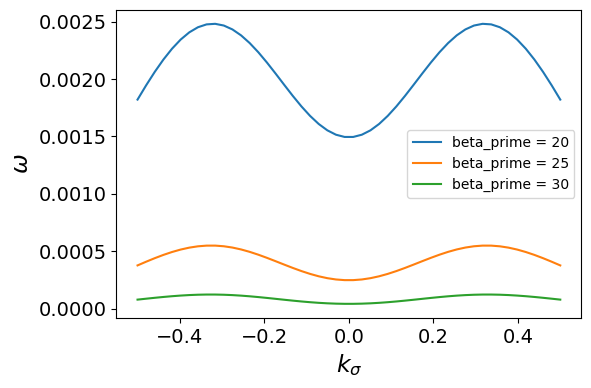

In [15]:
klist = np.linspace(-0.5, 0.5)
bp_list = [20,25,30]

plt.figure(figsize=(6,4))

for i in bp_list:
    omega_list = []
    beta_prime = i

    for j in klist:
        k_s = j
        spnc = spnc_anisotropy(0.4, 90, k_s, 45, beta_prime)
        omega_list.append(spnc.get_omega_prime())

    plt.plot(klist, omega_list, label=f'beta_prime = {i}')

plt.xlabel(r'$k_\sigma$',fontsize = 17)
plt.ylabel(r'$\omega$',fontsize = 17)
# plt.yscale('log')
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.legend(fontsize = 10)
plt.show()


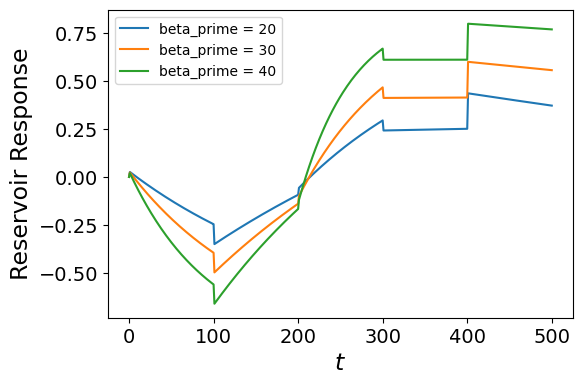

In [5]:
klist = np.random.uniform(-1,1,5)
# 画出不同beta_prime下，储层在不同k_s下的响应

bp_list = [20, 30, 40]

plt.figure(figsize=(6,4))

for beta_prime in bp_list:
    responses = []
    spn = spnc_anisotropy(0.4, 90, 0, 45, beta_prime)
    _,_,responses = spn.gen_trace_fast_delayed_feedback(klist,0.3, 100, params)

    plt.plot(responses, label=f'beta_prime = {beta_prime}')



plt.xlabel(r'$t$', fontsize=17)
plt.ylabel('Reservoir Response', fontsize=17)
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.legend(fontsize=10)

plt.show()


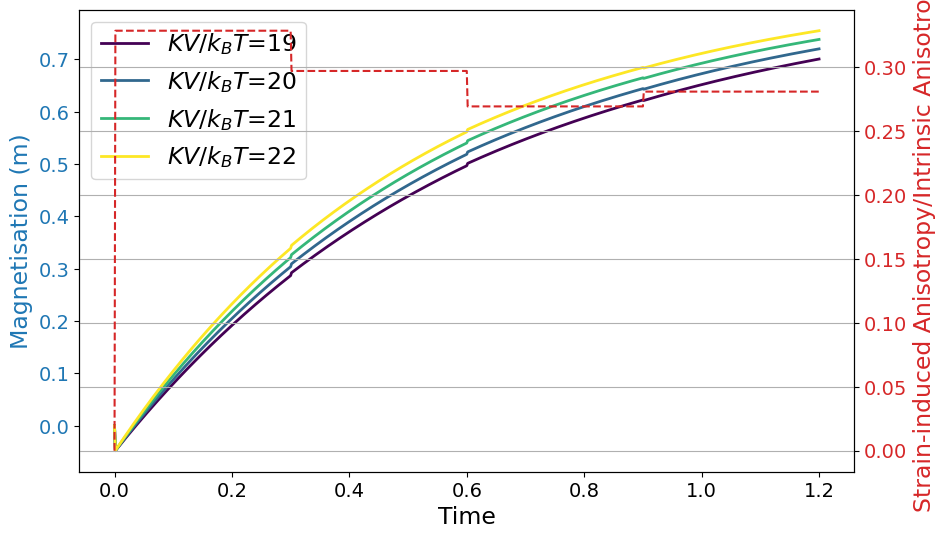

In [3]:
def plot_magnetic_properties(beta_primes):
    klist = np.random.uniform(-0.4, 0.4, 4)
    density = 200
    theta = 0.3
    beta_cons = 20

    # 自动生成颜色和标签
    colors = plt.cm.viridis(np.linspace(0, 1, len(beta_primes)))
    labels = [f'$KV/k_BT$={beta_prime}' for beta_prime in beta_primes]

    fig, ax1 = plt.subplots(figsize=(10, 6))

    for beta_prime, color, label in zip(beta_primes, colors, labels):
        spnc = spnc_anisotropy(0.4, 90, 0, 45, beta_prime)
        params = {
            'theta': 0.3,
            'gamma': 0,
            'beta_prime': beta_prime,
            'delay_feedback': 0,
            'Nvirt': 400 if beta_prime != 20 else 40
        }
        K_s, thetas, mags = spnc.gen_trace_fast_delayed_feedback(klist, theta, density, params, beta_cons)
        ax1.plot(thetas, mags, label=label, color=color, linewidth=2)
        if beta_prime == 20:
            K_s_main = K_s

    ax1.set_xlabel('Time', fontsize=17)
    ax1.set_ylabel('Magnetisation (m)', color='tab:blue', fontsize=17)
    ax1.tick_params(axis='y', labelcolor='tab:blue', labelsize=14)
    ax1.tick_params(axis='x', labelsize=14)
    plt.legend(fontsize=17)

    ax2 = ax1.twinx()
    ax2.plot(thetas, K_s_main, label='k', color='tab:red', linestyle='--')
    ax2.set_ylabel('Strain-induced Anisotropy/Intrinsic Anisotropy', color='tab:red', fontsize=17)
    ax2.tick_params(axis='y', labelcolor='tab:red', labelsize=14)

    plt.grid(True)
    plt.show()

# 调用函数并传递参数
beta_primes = [19, 20, 21,22]
plot_magnetic_properties(beta_primes)